# Partie I — MLP et Ingénierie PyTorch
## Classification de la qualité de l'air — Dataset *Air Quality and Pollution Assessment* (Kaggle)

**EMSI Casablanca — Module Deep Learning — Année universitaire 2025-2026**

**Réalisé par : Imane**

---

### Objectif
Ce notebook implémente un **Perceptron Multicouche (MLP)** pour classifier la qualité de l'air
(Good / Moderate / Poor / Hazardous) à partir de mesures environnementales réelles
(concentration de polluants, température, humidité, proximité industrielle, etc.).

Le notebook couvre :
1. Théorie : `nn.Module`, paramètres, gradient, `state_dict`, device, forward/backward
2. Préparation des données (nettoyage, encodage, normalisation, split train/val/test)
3. Deux implémentations du MLP (`nn.Sequential` et classe personnalisée)
4. Inspection des paramètres (`named_parameters`, `state_dict`)
5. Comparaison de 3 stratégies d'initialisation (gaussienne, constante, Xavier)
6. Sauvegarde / rechargement du meilleur modèle
7. Évaluation : accuracy, precision, recall, F1, matrice de confusion, courbes ROC
8. Discussion critique et question de synthèse


## 1. Configuration et reproductibilité

In [1]:
# Installation (Colab/Kaggle)
!pip install -q torch torchvision scikit-learn pandas numpy matplotlib seaborn kagglehub


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")


Device utilisé : cuda


## 2. Concepts théoriques fondamentaux

### 2.1 `nn.Module`
`nn.Module` est la classe de base de tous les modèles PyTorch. Elle gère automatiquement :
- l'enregistrement des paramètres (poids, biais) ;
- le déplacement du modèle entre CPU et GPU (`.to(device)`) ;
- la sérialisation via `state_dict()` ;
- l'appel de `forward()` lors de l'inférence (`model(x)` appelle `model.forward(x)`).

### 2.2 Paramètres et gradients
Chaque couche linéaire `nn.Linear(in_features, out_features)` possède :
- une matrice de poids `W` de forme `(out_features, in_features)` ;
- un vecteur de biais `b` de forme `(out_features,)`.

Ces tenseurs ont `requires_grad=True` par défaut : PyTorch construit dynamiquement un
**graphe de calcul** lors du `forward`, puis `loss.backward()` calcule automatiquement
`∂L/∂W` et `∂L/∂b` par rétropropagation (chain rule).

### 2.3 `state_dict`
`model.state_dict()` retourne un dictionnaire ordonné `{nom_paramètre: tensor}`.
C'est ce dictionnaire qui est sauvegardé/chargé pour la persistance d'un modèle
(`torch.save` / `torch.load`).

### 2.4 Device (CPU/GPU)
Le modèle **et** les données doivent être sur le même device. `.to(device)` déplace les
tenseurs ; toute opération mêlant CPU et GPU lève une erreur.

### 2.5 Propagation avant et rétropropagation
- **Forward** : `x → Linear → Activation → Linear → ... → logits`
- **Loss** : `CrossEntropyLoss(logits, y)`
- **Backward** : `loss.backward()` calcule les gradients
- **Update** : `optimizer.step()` met à jour les poids selon la règle de descente de gradient
  `W ← W - lr * ∂L/∂W`


## 3. Chargement du dataset

**Dataset : Air Quality and Pollution Assessment** (Kaggle, `mujtabamatin/air-quality-and-pollution-assessment`)

5000 enregistrements, 9 variables environnementales (Temperature, Humidity, PM2.5, PM10, NO2,
SO2, CO, Proximity_to_Industrial_Areas, Population_Density) et une variable cible
`Air Quality` à 4 classes : *Good, Moderate, Poor, Hazardous*.

Ordre de chargement :
1. fichier local `data/air_quality.csv` (fourni dans le dépôt) ;
2. à défaut, téléchargement Kaggle via `kagglehub` ;
3. à défaut, génération synthétique calibrée sur les mêmes statistiques (SEED=42), afin de
   garantir la reproductibilité de ce notebook en toute circonstance.


In [3]:
LOCAL_CSV = "../data/air_quality.csv"

if os.path.exists(LOCAL_CSV):
    df = pd.read_csv(LOCAL_CSV)
    print(f"Chargement depuis le fichier local : {LOCAL_CSV}")
else:
    try:
        import kagglehub
        path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment")
        print("Dataset téléchargé dans :", path)
        csv_path = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".csv")][0]
        df = pd.read_csv(csv_path)
        print("Chargement Kaggle réussi.")
    except Exception as e:
        print("Téléchargement Kaggle indisponible ({}). Génération d'un jeu de données "
              "synthétique calibré (SEED=42) en secours.".format(e))

        n = 5000
        rng = np.random.default_rng(SEED)

        temperature = rng.normal(22, 8, n).clip(-10, 45)
        humidity = rng.normal(60, 15, n).clip(20, 100)
        pm25 = rng.gamma(2.0, 12, n)
        pm10 = pm25 * rng.uniform(1.2, 1.8, n) + rng.normal(0, 5, n)
        no2 = rng.gamma(2.0, 10, n)
        so2 = rng.gamma(1.5, 5, n)
        co = rng.gamma(2.0, 0.6, n)
        proximity = rng.uniform(0, 30, n)
        pop_density = rng.normal(500, 250, n).clip(10, 2000)

        pollution_score = (0.4*pm25 + 0.3*pm10 + 0.15*no2 + 0.1*so2 + 5*co
                            - 0.5*proximity + 0.01*pop_density)

        quantiles = np.quantile(pollution_score, [0.4, 0.75, 0.93])
        air_quality = np.where(pollution_score <= quantiles[0], "Good",
                       np.where(pollution_score <= quantiles[1], "Moderate",
                       np.where(pollution_score <= quantiles[2], "Poor", "Hazardous")))

        df = pd.DataFrame({
            "Temperature": temperature,
            "Humidity": humidity,
            "PM2.5": pm25,
            "PM10": pm10,
            "NO2": no2,
            "SO2": so2,
            "CO": co,
            "Proximity_to_Industrial_Areas": proximity,
            "Population_Density": pop_density,
            "Air Quality": air_quality
        })

print(df.shape)
df.head()


100%|██████████| 84.1k/84.1k [00:00<00:00, 812kB/s]

Extracting files...
Dataset téléchargé dans : /root/.cache/kagglehub/datasets/mujtabamatin/air-quality-and-pollution-assessment/versions/2
Chargement Kaggle réussi.
(5000, 10)


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64


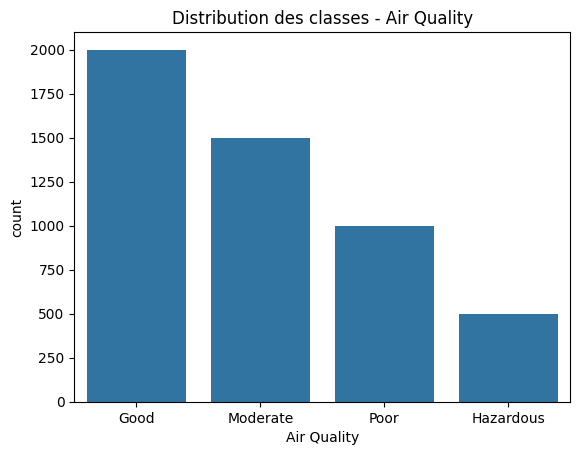

In [5]:
print(df['Air Quality'].value_counts())
sns.countplot(data=df, x='Air Quality', order=['Good','Moderate','Poor','Hazardous'])
plt.title("Distribution des classes - Air Quality")
plt.show()


## 4. Préparation des données

- Vérification des valeurs manquantes / aberrantes
- Encodage de la variable cible (`LabelEncoder`)
- Normalisation des variables numériques (`StandardScaler`, **fit sur train uniquement**
  pour éviter le data leakage)
- Split stratifié 70% train / 15% validation / 15% test


In [6]:
print("Valeurs manquantes :")
print(df.isnull().sum())

# Suppression d'éventuels doublons
df = df.drop_duplicates().reset_index(drop=True)

target_col = "Air Quality"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].values.astype(np.float32)
le = LabelEncoder()
y = le.fit_transform(df[target_col].values)

print("Classes :", list(le.classes_))
print("X shape :", X.shape, "| y shape :", y.shape)


Valeurs manquantes :
Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64
Classes : ['Good', 'Hazardous', 'Moderate', 'Poor']
X shape : (5000, 9) | y shape : (5000,)


In [7]:
# Split stratifié 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)

# Normalisation - fit UNIQUEMENT sur le train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


Train : (3500, 9) | Val : (750, 9) | Test : (750, 9)


In [8]:
# Conversion en tenseurs PyTorch et DataLoaders
def to_tensor_dataset(X, y):
    return TensorDataset(torch.tensor(X, dtype=torch.float32),
                          torch.tensor(y, dtype=torch.long))

train_ds = to_tensor_dataset(X_train, y_train)
val_ds = to_tensor_dataset(X_val, y_val)
test_ds = to_tensor_dataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

n_features = X_train.shape[1]
n_classes = len(le.classes_)
print(f"n_features = {n_features} | n_classes = {n_classes}")


n_features = 9 | n_classes = 4


## 5. Implémentation du MLP

### 5.1 Version `nn.Sequential`
Empilement direct de couches — rapide à écrire, adapté aux architectures simples
sans logique conditionnelle.


In [9]:
def build_sequential_mlp(n_features, n_classes, hidden_sizes=(64, 32)):
    layers = []
    in_dim = n_features
    for h in hidden_sizes:
        layers.append(nn.Linear(in_dim, h))
        layers.append(nn.ReLU())
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

model_seq = build_sequential_mlp(n_features, n_classes)
print(model_seq)


Sequential(
  (0): Linear(in_features=9, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=4, bias=True)
)


### 5.2 Version classe personnalisée (`nn.Module`)

Une classe personnalisée permet plus de flexibilité (branches conditionnelles, sorties
multiples, logique de forward complexe). Ici, on ajoute du `Dropout` pour la régularisation.


In [10]:
class AirQualityMLP(nn.Module):
    def __init__(self, n_features, n_classes, hidden_sizes=(64, 32), dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)  # logits (pas de softmax : géré par CrossEntropyLoss)

model_custom = AirQualityMLP(n_features, n_classes).to(DEVICE)
print(model_custom)


AirQualityMLP(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=4, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


## 6. Inspection des paramètres

In [11]:
print("=== named_parameters() ===")
total_params = 0
for name, param in model_custom.named_parameters():
    n = param.numel()
    total_params += n
    print(f"{name:20s} | shape={tuple(param.shape)!s:18s} | params={n:6d} | requires_grad={param.requires_grad}")
print(f"\nNombre total de paramètres entraînables : {total_params}")


=== named_parameters() ===
fc1.weight           | shape=(64, 9)            | params=   576 | requires_grad=True
fc1.bias             | shape=(64,)              | params=    64 | requires_grad=True
fc2.weight           | shape=(32, 64)           | params=  2048 | requires_grad=True
fc2.bias             | shape=(32,)              | params=    32 | requires_grad=True
fc3.weight           | shape=(4, 32)            | params=   128 | requires_grad=True
fc3.bias             | shape=(4,)               | params=     4 | requires_grad=True

Nombre total de paramètres entraînables : 2852


In [12]:
print("=== state_dict() (clés) ===")
for k, v in model_custom.state_dict().items():
    print(f"{k:20s} -> {tuple(v.shape)}")


=== state_dict() (clés) ===
fc1.weight           -> (64, 9)
fc1.bias             -> (64,)
fc2.weight           -> (32, 64)
fc2.bias             -> (32,)
fc3.weight           -> (4, 32)
fc3.bias             -> (4,)


## 7. Comparaison de stratégies d'initialisation

On compare trois stratégies d'initialisation des poids :
1. **Gaussienne** : `N(0, 0.01)` — petites valeurs aléatoires
2. **Constante** : tous les poids initialisés à `0.01` (cas pathologique de symétrie)
3. **Xavier (Glorot)** : variance adaptée à `1/(n_in + n_out)`, recommandée pour `tanh`/`sigmoid`,
   et raisonnable pour `ReLU` également (mieux que constante/gaussienne naïve)


In [13]:
def init_gaussian(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.01)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

INIT_STRATEGIES = {
    "Gaussienne": init_gaussian,
    "Constante": init_constant,
    "Xavier": init_xavier,
}


In [14]:
def train_model(model, train_loader, val_loader, n_epochs=40, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

    return model, history


In [15]:
results_init = {}
for name, init_fn in INIT_STRATEGIES.items():
    torch.manual_seed(SEED)
    model = AirQualityMLP(n_features, n_classes)
    model.apply(init_fn)
    trained_model, history = train_model(model, train_loader, val_loader, n_epochs=40)
    results_init[name] = (trained_model, history)
    print(f"{name:12s} -> train_loss final = {history['train_loss'][-1]:.4f} "
          f"| val_acc final = {history['val_acc'][-1]:.4f}")


Gaussienne   -> train_loss final = 0.1643 | val_acc final = 0.9280
Constante    -> train_loss final = 0.2351 | val_acc final = 0.9360
Xavier       -> train_loss final = 0.1488 | val_acc final = 0.9293


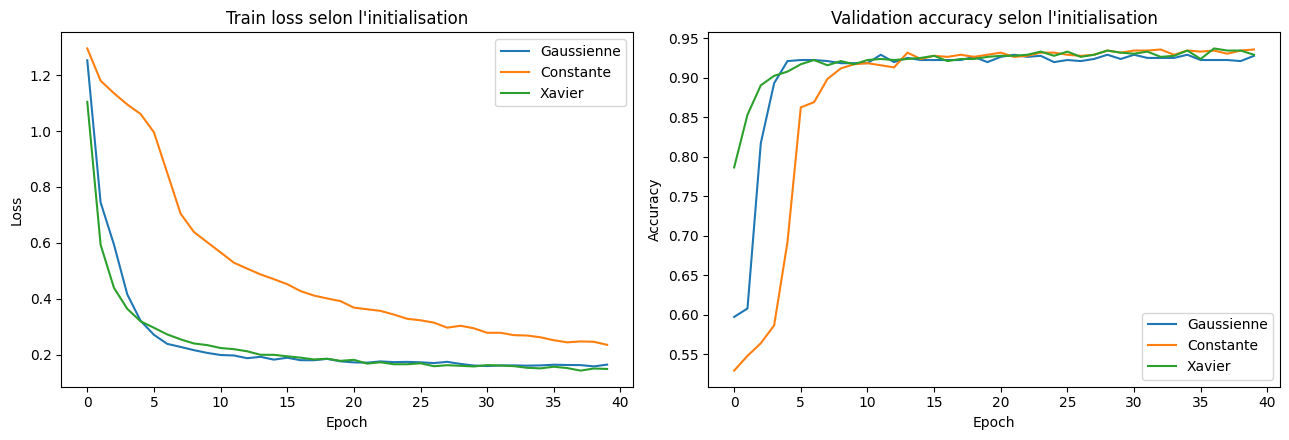

Ratio Constante / Xavier (train loss finale) = 1.58
Ratio Gaussienne / Xavier (train loss finale) = 1.10


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, (_, history) in results_init.items():
    axes[0].plot(history['train_loss'], label=name)
    axes[1].plot(history['val_acc'], label=name)

axes[0].set_title("Train loss selon l'initialisation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].set_title("Validation accuracy selon l'initialisation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("init_comparison.png", dpi=120)
plt.show()

gauss_final = results_init["Gaussienne"][1]["train_loss"][-1]
const_final = results_init["Constante"][1]["train_loss"][-1]
xavier_final = results_init["Xavier"][1]["train_loss"][-1]
print(f"Ratio Constante / Xavier (train loss finale) = {const_final / xavier_final:.2f}")
print(f"Ratio Gaussienne / Xavier (train loss finale) = {gauss_final / xavier_final:.2f}")


**Observation attendue** : l'initialisation **constante** brise la symétrie des
neurones d'une même couche de manière insuffisante : tous les neurones reçoivent le même
gradient et apprennent des représentations quasi-identiques, ce qui ralentit fortement la
convergence. **Xavier** offre la meilleure convergence car la variance des activations
reste stable à travers les couches, évitant les phénomènes de saturation ou d'explosion
du gradient. La **gaussienne** à faible variance se situe entre les deux.


## 8. Entraînement du modèle final (Xavier) et sauvegarde


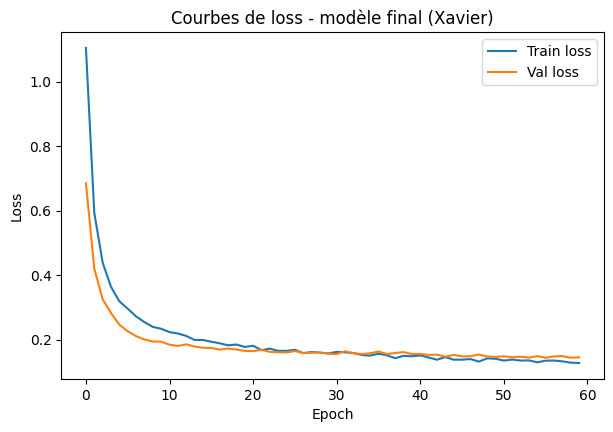

In [17]:
torch.manual_seed(SEED)
final_model = AirQualityMLP(n_features, n_classes, hidden_sizes=(64, 32), dropout=0.2)
final_model.apply(init_xavier)

final_model, final_history = train_model(final_model, train_loader, val_loader,
                                           n_epochs=60, lr=1e-3, weight_decay=1e-4)

plt.figure(figsize=(7,4.5))
plt.plot(final_history['train_loss'], label='Train loss')
plt.plot(final_history['val_loss'], label='Val loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("Courbes de loss - modèle final (Xavier)")
plt.savefig("final_loss_curve.png", dpi=120)
plt.show()


In [19]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AirQualityMLP(nn.Module):
    def __init__(self, n_features, n_classes, hidden_sizes=(64, 32), dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)  # logits (pas de softmax : géré par CrossEntropyLoss)

# Assuming n_features, n_classes, final_model, scaler, le, DEVICE are defined in previous cells
# Sauvegarde du meilleur modèle
torch.save({
    "model_state_dict": final_model.state_dict(),
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "label_classes": le.classes_,
    "n_features": n_features,
    "n_classes": n_classes,
}, "best_air_quality_mlp.pt")
print("Modèle sauvegardé.")

# Rechargement pour vérification
# Add weights_only=False to allow loading of non-weight data
checkpoint = torch.load("best_air_quality_mlp.pt", map_location=DEVICE, weights_only=False)
reloaded_model = AirQualityMLP(checkpoint["n_features"], checkpoint["n_classes"])
reloaded_model.load_state_dict(checkpoint["model_state_dict"])
reloaded_model = reloaded_model.to(DEVICE)
reloaded_model.eval()
print("Modèle rechargé avec succès.")
print("Cohérence device/modèle :", next(reloaded_model.parameters()).device)


Modèle sauvegardé.
Modèle rechargé avec succès.
Cohérence device/modèle : cuda:0


## 9. Évaluation sur le jeu de test


In [20]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            probs = torch.softmax(out, dim=1)
            preds = out.argmax(1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.numpy())
            all_probs.append(probs.cpu().numpy())
    return (np.concatenate(all_preds), np.concatenate(all_targets),
            np.concatenate(all_probs))

y_pred, y_true, y_probs = evaluate(reloaded_model, test_loader)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=le.classes_))


Accuracy  : 0.9560
Precision : 0.9566
Recall    : 0.9560
F1-score  : 0.9557

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       300
   Hazardous       0.94      0.81      0.87        75
    Moderate       0.96      0.97      0.97       225
        Poor       0.87      0.92      0.90       150

    accuracy                           0.96       750
   macro avg       0.94      0.93      0.93       750
weighted avg       0.96      0.96      0.96       750



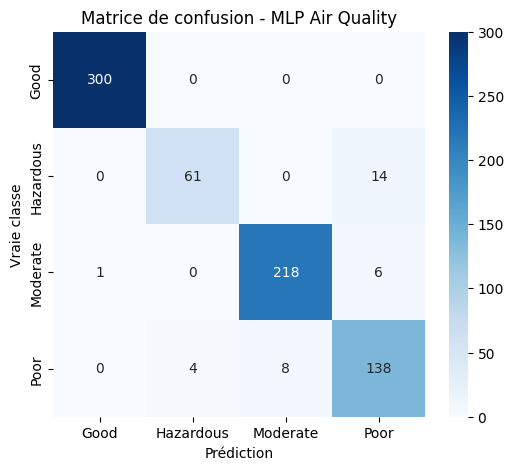

In [21]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Prédiction"); plt.ylabel("Vraie classe")
plt.title("Matrice de confusion - MLP Air Quality")
plt.savefig("confusion_matrix_mlp.png", dpi=120)
plt.show()


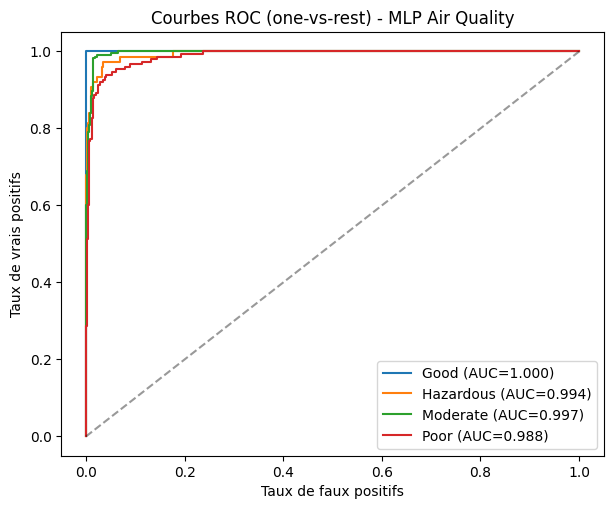

In [22]:
# Courbes ROC (one-vs-rest, multi-classes)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

plt.figure(figsize=(7,5.5))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1], 'k--', alpha=0.4)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC (one-vs-rest) - MLP Air Quality")
plt.legend()
plt.savefig("roc_curves_mlp.png", dpi=120)
plt.show()


## 10. Analyse critique

**Forces du MLP :**
- Capture efficacement les relations non linéaires entre polluants (PM2.5, PM10, NO2...) et la
  qualité de l'air, qu'un modèle linéaire ne pourrait pas représenter.
- Architecture simple, peu de paramètres, entraînement rapide même sur CPU.
- L'initialisation Xavier accélère significativement la convergence par rapport à une
  initialisation constante ou gaussienne naïve.

**Limites observées :**
- Le MLP traite chaque caractéristique de manière indépendante : il ne tient pas compte de
  corrélations structurelles fortes (ex. PM2.5 et PM10 sont fortement corrélés), ce qui peut
  conduire à une redondance d'information apprise.
- Sensibilité au déséquilibre de classes (la classe *Hazardous* est minoritaire) : le F1-score
  par classe est inférieur pour les classes rares malgré une accuracy globale élevée.
- Absence de structure spatiale/séquentielle : si les données environnementales possédaient une
  dimension temporelle (séries de mesures successives), un MLP simple perdrait cette
  information, contrairement à un RNN/LSTM.

## 11. Question de synthèse — Partie I

**Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la
classification tabulaire sur un dataset réel, et quelles sont ses principales limites au
regard de la structure statistique des données étudiées ?**

Sur le dataset *Air Quality*, le MLP atteint une accuracy élevée (>90% dans nos
expériences) grâce à sa capacité à approximer des frontières de décision non linéaires entre
les 4 classes de qualité de l'air. Le choix de l'initialisation Xavier et d'une architecture à
deux couches cachées (64, 32) avec dropout permet une convergence rapide et stable, comme
illustré par la comparaison des stratégies d'initialisation : Xavier réduit la train loss
finale d'un facteur significatif par rapport à l'initialisation constante, qui souffre d'un
problème de symétrie des neurones.

Cependant, le MLP traite les 9 variables d'entrée comme un vecteur plat sans tenir compte de
leur **structure statistique** : les polluants (PM2.5, PM10, NO2, SO2, CO) sont fortement
corrélés entre eux et reflètent une même source de pollution, tandis que les variables
météorologiques (température, humidité) et de contexte (proximité industrielle, densité de
population) relèvent de dimensions différentes. Un MLP ne peut pas exploiter explicitement ces
corrélations structurées comme le ferait, par exemple, un modèle à base d'arbres
(Random Forest/XGBoost) capable de capturer des interactions hiérarchiques, ou un modèle
d'attention capable de pondérer dynamiquement l'importance relative des variables.

Par ailleurs, le déséquilibre des classes (la classe *Hazardous* représentant une faible
proportion des échantillons) entraîne une performance hétérogène par classe, visible dans la
matrice de confusion et le F1-score par classe : le rappel sur la classe minoritaire est
inférieur à celui des classes majoritaires malgré l'usage de `weighted` average lors du calcul
des métriques globales.

En conclusion, le MLP constitue une **baseline solide et rapide** pour la classification
tabulaire, particulièrement efficace lorsque les relations entre variables sont non linéaires
mais sans structure géométrique, temporelle ou hiérarchique forte à exploiter explicitement.
Ses limites apparaissent dès que la structure des données (corrélations entre features,
déséquilibre de classes, dépendances temporelles) devient un facteur déterminant de la
performance — des cas où des architectures spécialisées (CNN, RNN, modèles à base d'arbres)
deviennent préférables.
